# Phase 4: Training Baseline (Sanity Run)

This notebook runs a short, reproducible training sanity check on a stratified subset of HAM10000. It validates the training loop, logs a small MLflow run, and saves metrics + plots under reports/ for later reporting.

In [10]:
from __future__ import annotations

from pathlib import Path
import json
import random
import sys

import numpy as np
import pandas as pd
import torch
import yaml
from torch.utils.data import DataLoader

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data.dataset import Ham10000Dataset, build_image_index
from src.models.efficientnet import MelanomaClassifier
from src.models.resnet_baseline import ResNetBaseline
from src.preprocessing.augmentation import get_train_transforms, get_val_transforms
from src.preprocessing.class_balancer import get_class_weights, get_weighted_sampler
from src.training.loss import FocalLoss
from src.training.trainer import MelanomaTrainer

artifact_dir = project_root / "reports" / "artifacts"
figure_dir = project_root / "reports" / "figures"
artifact_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

config_path = project_root / "configs" / "training" / "efficientnet_b0.yaml"
config = yaml.safe_load(config_path.read_text(encoding="utf-8"))
set_seed(int(config.get("seed", 42)))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(json.dumps({
    "project_root": str(project_root),
    "config_path": str(config_path),
    "device": str(device),
}, indent=2))

{
  "project_root": "/home/selba/Desktop/ENSIAS/Mlops/PFA/code",
  "config_path": "/home/selba/Desktop/ENSIAS/Mlops/PFA/code/configs/training/efficientnet_b0.yaml",
  "device": "cuda"
}


In [3]:
data_root = project_root / "data"
train_df = pd.read_csv(data_root / "splits" / "train_split.csv")
val_df = pd.read_csv(data_root / "splits" / "val_split.csv")

def ensure_label(df: pd.DataFrame) -> pd.DataFrame:
    if "label" in df.columns:
        return df
    df = df.copy()
    df["label"] = (df["dx"] == "mel").astype(int)
    return df

train_df = ensure_label(train_df)
val_df = ensure_label(val_df)

def stratified_sample(df: pd.DataFrame, n_per_class: int, seed: int) -> pd.DataFrame:
    samples = []
    for _, group in df.groupby("label"):
        samples.append(group.sample(n=min(n_per_class, len(group)), random_state=seed))
    return pd.concat(samples, ignore_index=True)

train_counts = train_df["label"].value_counts().sort_index().to_dict()
val_counts = val_df["label"].value_counts().sort_index().to_dict()

train_sample = stratified_sample(train_df, n_per_class=200, seed=42)
val_sample = stratified_sample(val_df, n_per_class=80, seed=42)

split_summary = {
    "train_counts": train_counts,
    "val_counts": val_counts,
    "train_sample_counts": train_sample["label"].value_counts().sort_index().to_dict(),
    "val_sample_counts": val_sample["label"].value_counts().sort_index().to_dict(),
    "train_sample_size": int(len(train_sample)),
    "val_sample_size": int(len(val_sample)),
}
split_summary_path = artifact_dir / "training_sanity_split_summary.json"
split_summary_path.write_text(json.dumps(split_summary, indent=2), encoding="utf-8")
print(f"Saved split summary to {split_summary_path}")
split_summary

Saved split summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/training_sanity_split_summary.json


{'train_counts': {0: 6219, 1: 771},
 'val_counts': {0: 1317, 1: 167},
 'train_sample_counts': {0: 200, 1: 200},
 'val_sample_counts': {0: 80, 1: 80},
 'train_sample_size': 400,
 'val_sample_size': 160}

In [5]:
image_index = build_image_index(data_root / "raw")
train_transforms = get_train_transforms()
val_transforms = get_val_transforms()

train_dataset = Ham10000Dataset(train_sample, image_index, transforms=train_transforms)
val_dataset = Ham10000Dataset(val_sample, image_index, transforms=val_transforms)

labels = train_sample["label"].astype(int).tolist()
class_weights = get_class_weights(labels, strategy="effective_num", beta=0.999)
sampler = get_weighted_sampler(labels, class_weights)

batch_size = 16
num_workers = 0
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

batch = next(iter(train_loader))
batch_summary = {
    "batch_images_shape": tuple(batch["image"].shape),
    "batch_labels_shape": tuple(batch["label"].shape),
    "batch_label_counts": pd.Series(batch["label"].tolist()).value_counts().to_dict(),
}
batch_summary_path = artifact_dir / "training_sanity_batch_summary.json"
batch_summary_path.write_text(json.dumps(batch_summary, indent=2), encoding="utf-8")
print(f"Saved batch summary to {batch_summary_path}")
batch_summary

Saved batch summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/training_sanity_batch_summary.json


/home/selba/Desktop/ENSIAS/Mlops/PFA/code/src/preprocessing/augmentation.py:34: UserWarning: Argument 'fill_value' is not valid and will be ignored.
  A.CoarseDropout(max_holes=8, max_height=INPUT_SIZE // 8, max_width=INPUT_SIZE // 8, fill_value=0, p=0.3),


{'batch_images_shape': (16, 3, 224, 224),
 'batch_labels_shape': (16,),
 'batch_label_counts': {0: 10, 1: 6}}

In [6]:
model_cfg = config.get("model", {})
model = MelanomaClassifier(
    model_name=model_cfg.get("name", "efficientnet_b0"),
    num_classes=int(model_cfg.get("num_classes", 2)),
    pretrained=bool(model_cfg.get("pretrained", True)),
    dropout_rate=float(model_cfg.get("dropout_rate", 0.3)),
)
criterion = FocalLoss(
    gamma=float(config.get("loss", {}).get("gamma", 2.0)),
    alpha=class_weights,
)

model = model.to(device)
images = batch["image"].to(device)
labels = batch["label"].to(device)

logits = model(images)
loss = criterion(logits, labels)

model_summary = {
    "model_name": model.model_name,
    "total_params": int(sum(p.numel() for p in model.parameters())),
    "trainable_params": int(sum(p.numel() for p in model.parameters() if p.requires_grad)),
    "batch_logits_shape": tuple(logits.shape),
    "batch_loss": float(loss.item()),
}
model_summary_path = artifact_dir / "training_sanity_model_summary.json"
model_summary_path.write_text(json.dumps(model_summary, indent=2), encoding="utf-8")
print(f"Saved model summary to {model_summary_path}")
model_summary

Saved model summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/training_sanity_model_summary.json


{'model_name': 'efficientnet_b0',
 'total_params': 4339070,
 'trainable_params': 4339070,
 'batch_logits_shape': (16, 2),
 'batch_loss': 6.627020835876465}

2026/05/27 20:43:27 INFO mlflow.tracking.fluent: Experiment with name 'melanoma-sanity' does not exist. Creating a new experiment.
2026/05/27 20:43:56 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/27 20:43:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


MLflow run id: 71ddd60745f74771bc29dc1d88aa5a71
Saved metric history to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/training_sanity_metrics.json
Saved metrics plot to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/training_sanity_metrics.png


{'run_id': '71ddd60745f74771bc29dc1d88aa5a71',
 'tracking_uri': 'file:///home/selba/Desktop/ENSIAS/Mlops/PFA/code/mlflow',
 'best_val_auc': 0.7425,
 'metrics_plot': '/home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/training_sanity_metrics.png'}

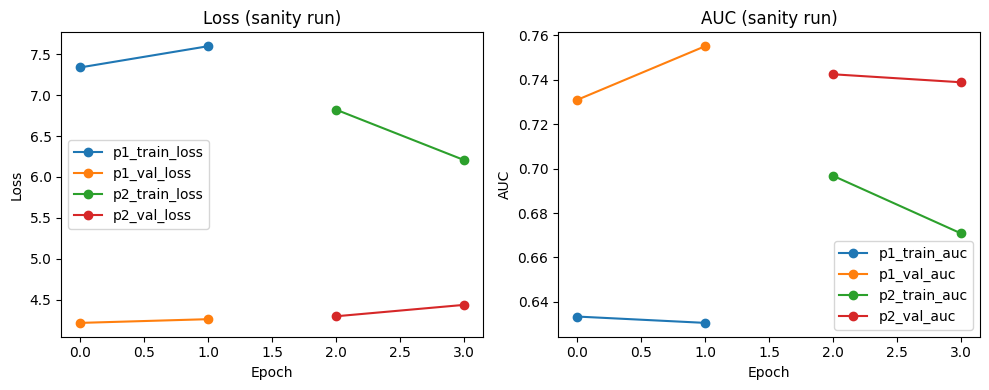

In [7]:
import matplotlib.pyplot as plt
import mlflow
from mlflow.tracking import MlflowClient

mlflow_dir = project_root / "mlflow"
mlflow_dir.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri(mlflow_dir.as_uri())

sanity_config = dict(config)
sanity_config["experiment_name"] = "melanoma-sanity"
sanity_config["training"] = dict(config.get("training", {}))
sanity_config["training"].update({
    "phase1_epochs": 2,
    "phase2_epochs": 2,
    "patience": 2,
})
sanity_config["data"] = dict(config.get("data", {}))
sanity_config["data"]["batch_size"] = batch_size

trainer = MelanomaTrainer(sanity_config)
run_id = trainer.train(model, train_loader, val_loader, criterion, run_name="sanity-subset")
print(f"MLflow run id: {run_id}")

client = MlflowClient()
metric_keys = [
    "p1_train_loss", "p1_val_loss",
    "p2_train_loss", "p2_val_loss",
    "p1_train_auc", "p1_val_auc",
    "p2_train_auc", "p2_val_auc",
]
metric_history = {}
for key in metric_keys:
    history = client.get_metric_history(run_id, key)
    metric_history[key] = [{"step": m.step, "value": m.value} for m in history]

metrics_path = artifact_dir / "training_sanity_metrics.json"
metrics_path.write_text(json.dumps(metric_history, indent=2), encoding="utf-8")
print(f"Saved metric history to {metrics_path}")

loss_keys = ["p1_train_loss", "p1_val_loss", "p2_train_loss", "p2_val_loss"]
auc_keys = ["p1_train_auc", "p1_val_auc", "p2_train_auc", "p2_val_auc"]

def history_to_frame(keys: list[str]) -> pd.DataFrame:
    rows = []
    for key in keys:
        for item in metric_history.get(key, []):
            rows.append({"key": key, "step": item["step"], "value": item["value"]})
    return pd.DataFrame(rows)

loss_df = history_to_frame(loss_keys)
auc_df = history_to_frame(auc_keys)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
if not loss_df.empty:
    for key in loss_keys:
        subset = loss_df[loss_df["key"] == key]
        if not subset.empty:
            axes[0].plot(subset["step"], subset["value"], marker="o", label=key)
    axes[0].set_title("Loss (sanity run)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, "No loss metrics logged", ha="center", va="center")

if not auc_df.empty:
    for key in auc_keys:
        subset = auc_df[auc_df["key"] == key]
        if not subset.empty:
            axes[1].plot(subset["step"], subset["value"], marker="o", label=key)
    axes[1].set_title("AUC (sanity run)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("AUC")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "No AUC metrics logged", ha="center", va="center")

fig.tight_layout()
metrics_plot_path = figure_dir / "training_sanity_metrics.png"
fig.savefig(metrics_plot_path, dpi=160, bbox_inches="tight")
print(f"Saved metrics plot to {metrics_plot_path}")

best_auc_history = client.get_metric_history(run_id, "best_val_auc")
best_val_auc = best_auc_history[-1].value if best_auc_history else None

run_summary = {
    "run_id": run_id,
    "tracking_uri": mlflow.get_tracking_uri(),
    "best_val_auc": best_val_auc,
    "metrics_plot": str(metrics_plot_path),
}
run_summary_path = artifact_dir / "training_sanity_run_summary.json"
run_summary_path.write_text(json.dumps(run_summary, indent=2), encoding="utf-8")
run_summary

# Phase 4: Full Training Run (EfficientNet-B0)

Run the full dataset with the standard config and record metrics and plots for the report.

In [8]:
data_cfg = config.get("data", {})
loss_cfg = config.get("loss", {})

full_train_df = train_df.copy()
full_val_df = val_df.copy()

labels_full = full_train_df["label"].astype(int).tolist()
class_weights_full = get_class_weights(
    labels_full,
    strategy=loss_cfg.get("class_weight_strategy", "effective_num"),
    beta=float(loss_cfg.get("beta", 0.999)),
)
sampler_full = get_weighted_sampler(labels_full, class_weights_full)

batch_size_full = int(data_cfg.get("batch_size", 32))
num_workers_full = int(data_cfg.get("num_workers", 4))
pin_memory_full = bool(data_cfg.get("pin_memory", True)) and torch.cuda.is_available()

full_train_dataset = Ham10000Dataset(full_train_df, image_index, transforms=train_transforms)
full_val_dataset = Ham10000Dataset(full_val_df, image_index, transforms=val_transforms)

full_train_loader = DataLoader(
    full_train_dataset,
    batch_size=batch_size_full,
    sampler=sampler_full,
    num_workers=num_workers_full,
    pin_memory=pin_memory_full,
)
full_val_loader = DataLoader(
    full_val_dataset,
    batch_size=batch_size_full,
    shuffle=False,
    num_workers=num_workers_full,
    pin_memory=pin_memory_full,
)

full_batch = next(iter(full_train_loader))
full_batch_summary = {
    "batch_images_shape": tuple(full_batch["image"].shape),
    "batch_labels_shape": tuple(full_batch["label"].shape),
    "batch_label_counts": pd.Series(full_batch["label"].tolist()).value_counts().to_dict(),
}

data_summary = {
    "train_size": int(len(full_train_df)),
    "val_size": int(len(full_val_df)),
    "train_class_counts": full_train_df["label"].value_counts().sort_index().to_dict(),
    "val_class_counts": full_val_df["label"].value_counts().sort_index().to_dict(),
    "class_weights": class_weights_full.tolist(),
    "batch_size": batch_size_full,
    "num_workers": num_workers_full,
}

data_summary_path = artifact_dir / "training_full_data_summary.json"
batch_summary_path = artifact_dir / "training_full_batch_summary.json"
data_summary_path.write_text(json.dumps(data_summary, indent=2), encoding="utf-8")
batch_summary_path.write_text(json.dumps(full_batch_summary, indent=2), encoding="utf-8")
print(f"Saved full data summary to {data_summary_path}")
print(f"Saved full batch summary to {batch_summary_path}")
{"data_summary": data_summary, "batch_summary": full_batch_summary}

Saved full data summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/training_full_data_summary.json
Saved full batch summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/training_full_batch_summary.json


{'data_summary': {'train_size': 6990,
  'val_size': 1484,
  'train_class_counts': {0: 6219, 1: 771},
  'val_class_counts': {0: 1317, 1: 167},
  'class_weights': [0.7001997232437134, 1.2998002767562866],
  'batch_size': 32,
  'num_workers': 4},
 'batch_summary': {'batch_images_shape': (32, 3, 224, 224),
  'batch_labels_shape': (32,),
  'batch_label_counts': {0: 26, 1: 6}}}

2026/05/27 20:47:31 INFO mlflow.tracking.fluent: Experiment with name 'melanoma-detection-efficientnet' does not exist. Creating a new experiment.
2026/05/27 21:03:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/27 21:03:06 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


MLflow run id: 9c74ae3a097a4f2f968767c0882c9262
Saved metric history to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/training_full_metrics.json
Saved metrics plot to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/training_full_metrics.png


{'run_id': '9c74ae3a097a4f2f968767c0882c9262',
 'tracking_uri': 'file:///home/selba/Desktop/ENSIAS/Mlops/PFA/code/mlflow',
 'best_val_auc': 0.8687181445764507,
 'metrics_plot': '/home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/training_full_metrics.png'}

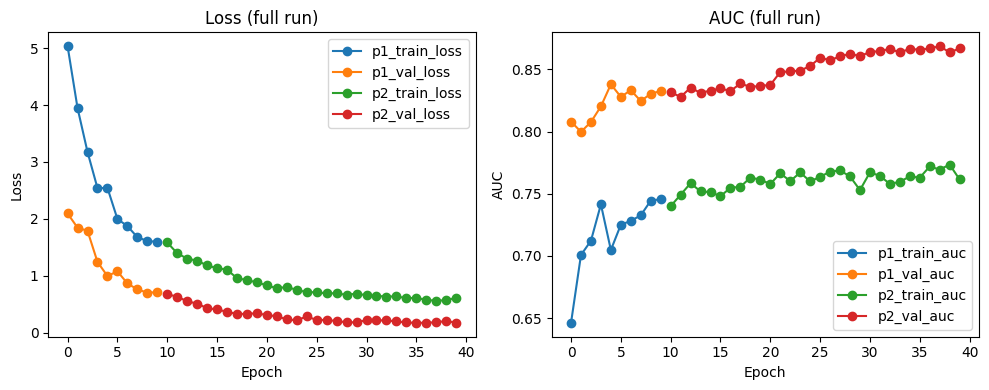

In [9]:
import matplotlib.pyplot as plt
import mlflow
from mlflow.tracking import MlflowClient

mlflow_dir = project_root / "mlflow"
mlflow_dir.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri(mlflow_dir.as_uri())

model_cfg = config.get("model", {})
model_full = MelanomaClassifier(
    model_name=model_cfg.get("name", "efficientnet_b0"),
    num_classes=int(model_cfg.get("num_classes", 2)),
    pretrained=bool(model_cfg.get("pretrained", True)),
    dropout_rate=float(model_cfg.get("dropout_rate", 0.3)),
)
criterion_full = FocalLoss(
    gamma=float(loss_cfg.get("gamma", 2.0)),
    alpha=class_weights_full,
)

trainer_full = MelanomaTrainer(config)
run_id_full = trainer_full.train(
    model_full,
    full_train_loader,
    full_val_loader,
    criterion_full,
    run_name="efficientnet_full",
)
print(f"MLflow run id: {run_id_full}")

client = MlflowClient()
metric_keys = [
    "p1_train_loss", "p1_val_loss",
    "p2_train_loss", "p2_val_loss",
    "p1_train_auc", "p1_val_auc",
    "p2_train_auc", "p2_val_auc",
]
metric_history = {}
for key in metric_keys:
    history = client.get_metric_history(run_id_full, key)
    metric_history[key] = [{"step": m.step, "value": m.value} for m in history]

metrics_path = artifact_dir / "training_full_metrics.json"
metrics_path.write_text(json.dumps(metric_history, indent=2), encoding="utf-8")
print(f"Saved metric history to {metrics_path}")

loss_keys = ["p1_train_loss", "p1_val_loss", "p2_train_loss", "p2_val_loss"]
auc_keys = ["p1_train_auc", "p1_val_auc", "p2_train_auc", "p2_val_auc"]

def history_to_frame(keys: list[str]) -> pd.DataFrame:
    rows = []
    for key in keys:
        for item in metric_history.get(key, []):
            rows.append({"key": key, "step": item["step"], "value": item["value"]})
    return pd.DataFrame(rows)

loss_df = history_to_frame(loss_keys)
auc_df = history_to_frame(auc_keys)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
if not loss_df.empty:
    for key in loss_keys:
        subset = loss_df[loss_df["key"] == key]
        if not subset.empty:
            axes[0].plot(subset["step"], subset["value"], marker="o", label=key)
    axes[0].set_title("Loss (full run)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, "No loss metrics logged", ha="center", va="center")

if not auc_df.empty:
    for key in auc_keys:
        subset = auc_df[auc_df["key"] == key]
        if not subset.empty:
            axes[1].plot(subset["step"], subset["value"], marker="o", label=key)
    axes[1].set_title("AUC (full run)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("AUC")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "No AUC metrics logged", ha="center", va="center")

fig.tight_layout()
metrics_plot_path = figure_dir / "training_full_metrics.png"
fig.savefig(metrics_plot_path, dpi=160, bbox_inches="tight")
print(f"Saved metrics plot to {metrics_plot_path}")

best_auc_history = client.get_metric_history(run_id_full, "best_val_auc")
best_val_auc = best_auc_history[-1].value if best_auc_history else None

run_summary = {
    "run_id": run_id_full,
    "tracking_uri": mlflow.get_tracking_uri(),
    "best_val_auc": best_val_auc,
    "metrics_plot": str(metrics_plot_path),
}
run_summary_path = artifact_dir / "training_full_run_summary.json"
run_summary_path.write_text(json.dumps(run_summary, indent=2), encoding="utf-8")
run_summary

# Phase 4: Full Training Run (ResNet50 Baseline)

Train the ResNet50 baseline on the full dataset and save metrics plus plots for comparison.

In [11]:
resnet_config_path = project_root / "configs" / "training" / "resnet50_baseline.yaml"
resnet_config = yaml.safe_load(resnet_config_path.read_text(encoding="utf-8"))
set_seed(int(resnet_config.get("seed", 42)))

def ensure_label_resnet(df: pd.DataFrame) -> pd.DataFrame:
    if "label" in df.columns:
        return df
    df = df.copy()
    df["label"] = (df["dx"] == "mel").astype(int)
    return df

data_root = project_root / "data"
if "train_df" not in globals():
    train_df = ensure_label_resnet(pd.read_csv(data_root / "splits" / "train_split.csv"))
    val_df = ensure_label_resnet(pd.read_csv(data_root / "splits" / "val_split.csv"))
else:
    train_df = ensure_label_resnet(train_df)
    val_df = ensure_label_resnet(val_df)

if "image_index" not in globals():
    image_index = build_image_index(data_root / "raw")
if "train_transforms" not in globals():
    train_transforms = get_train_transforms()
    val_transforms = get_val_transforms()

full_train_df_resnet = train_df.copy()
full_val_df_resnet = val_df.copy()

data_cfg_resnet = resnet_config.get("data", {})
loss_cfg_resnet = resnet_config.get("loss", {})

labels_full_resnet = full_train_df_resnet["label"].astype(int).tolist()
class_weights_resnet = get_class_weights(
    labels_full_resnet,
    strategy=loss_cfg_resnet.get("class_weight_strategy", "effective_num"),
    beta=float(loss_cfg_resnet.get("beta", 0.999)),
)
sampler_resnet = get_weighted_sampler(labels_full_resnet, class_weights_resnet)

batch_size_resnet = int(data_cfg_resnet.get("batch_size", 32))
num_workers_resnet = int(data_cfg_resnet.get("num_workers", 4))
pin_memory_resnet = bool(data_cfg_resnet.get("pin_memory", True)) and torch.cuda.is_available()

train_dataset_resnet = Ham10000Dataset(full_train_df_resnet, image_index, transforms=train_transforms)
val_dataset_resnet = Ham10000Dataset(full_val_df_resnet, image_index, transforms=val_transforms)

train_loader_resnet = DataLoader(
    train_dataset_resnet,
    batch_size=batch_size_resnet,
    sampler=sampler_resnet,
    num_workers=num_workers_resnet,
    pin_memory=pin_memory_resnet,
)
val_loader_resnet = DataLoader(
    val_dataset_resnet,
    batch_size=batch_size_resnet,
    shuffle=False,
    num_workers=num_workers_resnet,
    pin_memory=pin_memory_resnet,
)

batch_resnet = next(iter(train_loader_resnet))
batch_summary_resnet = {
    "batch_images_shape": tuple(batch_resnet["image"].shape),
    "batch_labels_shape": tuple(batch_resnet["label"].shape),
    "batch_label_counts": pd.Series(batch_resnet["label"].tolist()).value_counts().to_dict(),
}

data_summary_resnet = {
    "config_path": str(resnet_config_path),
    "train_size": int(len(full_train_df_resnet)),
    "val_size": int(len(full_val_df_resnet)),
    "train_class_counts": full_train_df_resnet["label"].value_counts().sort_index().to_dict(),
    "val_class_counts": full_val_df_resnet["label"].value_counts().sort_index().to_dict(),
    "class_weights": class_weights_resnet.tolist(),
    "batch_size": batch_size_resnet,
    "num_workers": num_workers_resnet,
}

data_summary_path_resnet = artifact_dir / "training_resnet_data_summary.json"
batch_summary_path_resnet = artifact_dir / "training_resnet_batch_summary.json"
data_summary_path_resnet.write_text(json.dumps(data_summary_resnet, indent=2), encoding="utf-8")
batch_summary_path_resnet.write_text(json.dumps(batch_summary_resnet, indent=2), encoding="utf-8")
print(f"Saved ResNet data summary to {data_summary_path_resnet}")
print(f"Saved ResNet batch summary to {batch_summary_path_resnet}")
{"data_summary": data_summary_resnet, "batch_summary": batch_summary_resnet}

Saved ResNet data summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/training_resnet_data_summary.json
Saved ResNet batch summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/training_resnet_batch_summary.json


{'data_summary': {'config_path': '/home/selba/Desktop/ENSIAS/Mlops/PFA/code/configs/training/resnet50_baseline.yaml',
  'train_size': 6990,
  'val_size': 1484,
  'train_class_counts': {0: 6219, 1: 771},
  'val_class_counts': {0: 1317, 1: 167},
  'class_weights': [0.7001997232437134, 1.2998002767562866],
  'batch_size': 32,
  'num_workers': 4},
 'batch_summary': {'batch_images_shape': (32, 3, 224, 224),
  'batch_labels_shape': (32,),
  'batch_label_counts': {0: 23, 1: 9}}}

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

2026/05/27 21:05:33 INFO mlflow.tracking.fluent: Experiment with name 'melanoma-detection-resnet50' does not exist. Creating a new experiment.
2026/05/27 21:30:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/27 21:30:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


MLflow run id: b8badf8092e840efa7cdacf9acffb76b
Saved ResNet metric history to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/training_resnet_metrics.json
Saved ResNet metrics plot to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/training_resnet_metrics.png


{'run_id': 'b8badf8092e840efa7cdacf9acffb76b',
 'tracking_uri': 'file:///home/selba/Desktop/ENSIAS/Mlops/PFA/code/mlflow',
 'best_val_auc': 0.8402056933968055,
 'metrics_plot': '/home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/training_resnet_metrics.png'}

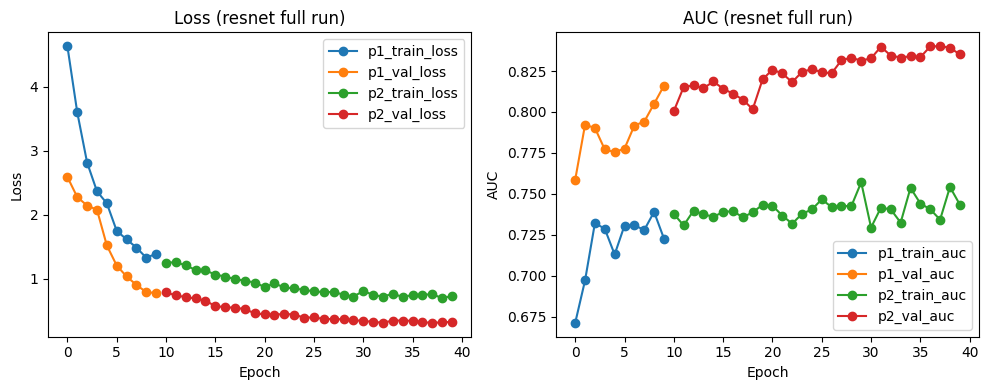

In [12]:
import matplotlib.pyplot as plt
import mlflow
from mlflow.tracking import MlflowClient

mlflow_dir = project_root / "mlflow"
mlflow_dir.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri(mlflow_dir.as_uri())

model_cfg_resnet = resnet_config.get("model", {})
model_resnet = ResNetBaseline(
    model_name=model_cfg_resnet.get("name", "resnet50"),
    num_classes=int(model_cfg_resnet.get("num_classes", 2)),
    pretrained=bool(model_cfg_resnet.get("pretrained", True)),
    dropout_rate=float(model_cfg_resnet.get("dropout_rate", 0.2)),
)
criterion_resnet = FocalLoss(
    gamma=float(loss_cfg_resnet.get("gamma", 2.0)),
    alpha=class_weights_resnet,
 )

trainer_resnet = MelanomaTrainer(resnet_config)
run_id_resnet = trainer_resnet.train(
    model_resnet,
    train_loader_resnet,
    val_loader_resnet,
    criterion_resnet,
    run_name="resnet50_full",
)
print(f"MLflow run id: {run_id_resnet}")

client = MlflowClient()
metric_keys = [
    "p1_train_loss", "p1_val_loss",
    "p2_train_loss", "p2_val_loss",
    "p1_train_auc", "p1_val_auc",
    "p2_train_auc", "p2_val_auc",
]
metric_history_resnet = {}
for key in metric_keys:
    history = client.get_metric_history(run_id_resnet, key)
    metric_history_resnet[key] = [{"step": m.step, "value": m.value} for m in history]

metrics_path_resnet = artifact_dir / "training_resnet_metrics.json"
metrics_path_resnet.write_text(json.dumps(metric_history_resnet, indent=2), encoding="utf-8")
print(f"Saved ResNet metric history to {metrics_path_resnet}")

loss_keys = ["p1_train_loss", "p1_val_loss", "p2_train_loss", "p2_val_loss"]
auc_keys = ["p1_train_auc", "p1_val_auc", "p2_train_auc", "p2_val_auc"]

def history_to_frame(keys: list[str]) -> pd.DataFrame:
    rows = []
    for key in keys:
        for item in metric_history_resnet.get(key, []):
            rows.append({"key": key, "step": item["step"], "value": item["value"]})
    return pd.DataFrame(rows)

loss_df = history_to_frame(loss_keys)
auc_df = history_to_frame(auc_keys)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
if not loss_df.empty:
    for key in loss_keys:
        subset = loss_df[loss_df["key"] == key]
        if not subset.empty:
            axes[0].plot(subset["step"], subset["value"], marker="o", label=key)
    axes[0].set_title("Loss (resnet full run)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, "No loss metrics logged", ha="center", va="center")

if not auc_df.empty:
    for key in auc_keys:
        subset = auc_df[auc_df["key"] == key]
        if not subset.empty:
            axes[1].plot(subset["step"], subset["value"], marker="o", label=key)
    axes[1].set_title("AUC (resnet full run)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("AUC")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "No AUC metrics logged", ha="center", va="center")

fig.tight_layout()
metrics_plot_path_resnet = figure_dir / "training_resnet_metrics.png"
fig.savefig(metrics_plot_path_resnet, dpi=160, bbox_inches="tight")
print(f"Saved ResNet metrics plot to {metrics_plot_path_resnet}")

best_auc_history = client.get_metric_history(run_id_resnet, "best_val_auc")
best_val_auc = best_auc_history[-1].value if best_auc_history else None

run_summary_resnet = {
    "run_id": run_id_resnet,
    "tracking_uri": mlflow.get_tracking_uri(),
    "best_val_auc": best_val_auc,
    "metrics_plot": str(metrics_plot_path_resnet),
}
run_summary_path_resnet = artifact_dir / "training_resnet_run_summary.json"
run_summary_path_resnet.write_text(json.dumps(run_summary_resnet, indent=2), encoding="utf-8")
run_summary_resnet